Loads the dataset from CSV into a DataFrame and previews the first rows.

Loads the SolarPath dataset, builds weather lag/rolling features, and splits it chronologically into train/validation/test sets for Prophet. Irradiation and is_daylight are excluded from the regressor list since both leak information about the target (actual_ratio is derived from irradiation, and is_daylight directly determines whether actual_ratio is zero).

In [161]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Load the data
df_solarpath = pd.read_csv('/content/solarpath_day1_clean_datasett.csv')
df_feat = df_solarpath.copy()

# 2. Parse timestamps and sort chronologically
if 'timestamp' in df_feat.columns:
    df_feat['timestamp'] = pd.to_datetime(df_feat['timestamp'], format='mixed', errors='coerce')
    df_feat = df_feat.sort_values('timestamp').reset_index(drop=True)

# 3. Weather lag/rolling features (irradiation excluded — it leaks the target)
weather_cols = ['temp_module', 'temp_ambient', 'humidity', 'wind_speed']

for col in weather_cols:
    if col in df_feat.columns:
        df_feat[f'{col}_lag1'] = df_feat[col].shift(1)
        df_feat[f'{col}_lag2'] = df_feat[col].shift(2)
        df_feat[f'{col}_roll_mean_3'] = df_feat[col].rolling(window=3, min_periods=1).mean()
        df_feat[f'{col}_roll_std_3'] = df_feat[col].rolling(window=3, min_periods=1).std().fillna(0)

df_feat = df_feat.dropna().reset_index(drop=True)

# 4. Drop columns not needed for training
cols_to_drop = ['PLANT_ID', 'SOURCE_KEY', 'site_id', 'latitude', 'longitude']
df_feat_clean = df_feat.drop(columns=[col for col in cols_to_drop if col in df_feat.columns])

# 5. Regressors kept to reduced, non-redundant set (rolling means only,
#    to limit multicollinearity between raw values and their own rolling stats)
prophet_regressors = [
    'temp_module_roll_mean_3',
    'temp_ambient_roll_mean_3',
    'wind_speed_roll_mean_3',
    'humidity_roll_mean_3',
]
prophet_regressors = [col for col in prophet_regressors if col in df_feat_clean.columns]
print(f"Regressors used for training: {prophet_regressors}")

# 6. Chronological split (70% train / 15% val / 15% test)
train_end = int(len(df_feat_clean) * 0.70)
val_end = int(len(df_feat_clean) * 0.85)

prophet_train = df_feat_clean.iloc[:train_end][['timestamp', 'actual_ratio'] + prophet_regressors].rename(
    columns={'timestamp': 'ds', 'actual_ratio': 'y'}
)
prophet_val = df_feat_clean.iloc[train_end:val_end][['timestamp', 'actual_ratio'] + prophet_regressors].rename(
    columns={'timestamp': 'ds', 'actual_ratio': 'y'}
)
prophet_test = df_feat_clean.iloc[val_end:][['timestamp', 'actual_ratio'] + prophet_regressors].rename(
    columns={'timestamp': 'ds', 'actual_ratio': 'y'}
)

# Floor at 0 (power output can't be negative)
prophet_train['floor'] = 0
prophet_val['floor'] = 0
prophet_test['floor'] = 0
df_feat.head()


Regressors used for training: ['temp_module_roll_mean_3', 'temp_ambient_roll_mean_3', 'wind_speed_roll_mean_3', 'humidity_roll_mean_3']


,timestamp,PLANT_ID,SOURCE_KEY,actual_dc_power,AC_POWER,DAILY_YIELD,TOTAL_YIELD,temp_ambient,temp_module,irradiation,site_id,wind_speed,humidity,latitude,longitude,is_daylight,actual_ratio,temp_module_lag1,temp_module_lag2,temp_module_roll_mean_3,temp_module_roll_std_3,temp_ambient_lag1,temp_ambient_lag2,temp_ambient_roll_mean_3,temp_ambient_roll_std_3,humidity_lag1,humidity_lag2,humidity_roll_mean_3,humidity_roll_std_3,wind_speed_lag1,wind_speed_lag2,wind_speed_roll_mean_3,wind_speed_roll_std_3
0,2020-05-15,4136001,4UPUqMRk7TRMgml,0.0,0.0,9425.000000,2.429011e+06,27.004764,25.060789,0.0,PLANT_2_IN,3.01,69.91,20.76,72.86,False,0.0,22.857507,22.857507,23.591935,1.272065,25.184316,25.184316,25.791132,1.051036,69.91,69.91,69.91,0.0,3.01,3.01,3.01,0.0
1,2020-05-15,4136001,81aHJ1q11NBPMrL,0.0,0.0,0.000000,1.215279e+09,27.004764,25.060789,0.0,PLANT_2_IN,3.01,69.91,20.76,72.86,False,0.0,25.060789,22.857507,24.326362,1.272065,27.004764,25.184316,26.397948,1.051036,69.91,69.91,69.91,0.0,3.01,3.01,3.01,0.0
2,2020-05-15,4136001,q49J1IKaHRwDQnt,0.0,0.0,4315.000000,3.399230e+05,27.004764,25.060789,0.0,PLANT_2_IN,3.01,69.91,20.76,72.86,False,0.0,25.060789,25.060789,25.060789,0.000000,27.004764,27.004764,27.004764,0.000000,69.91,69.91,69.91,0.0,3.01,3.01,3.01,0.0
3,2020-05-15,4136001,9kRcWv60rDACzjR,0.0,0.0,3075.333333,2.247720e+09,27.004764,25.060789,0.0,PLANT_2_IN,3.01,69.91,20.76,72.86,False,0.0,25.060789,25.060789,25.060789,0.000000,27.004764,27.004764,27.004764,0.000000,69.91,69.91,69.91,0.0,3.01,3.01,3.01,0.0
4,2020-05-15,4136001,Et9kgGMDl729KT4,0.0,0.0,269.933333,1.704250e+06,27.004764,25.060789,0.0,PLANT_2_IN,3.01,69.91,20.76,72.86,False,0.0,25.060789,25.060789,25.060789,0.000000,27.004764,27.004764,27.004764,0.000000,69.91,69.91,69.91,0.0,3.01,3.01,3.01,0.0


In [180]:
df_feat_clean.to_csv('df_feat_clean.csv', index=False)

Trains the Prophet model with a custom daily seasonality to capture the sunrise/sunset curve, evaluates it on the held-out test set, adds its results to the model comparison table, and plots each regressor's contribution variability to the forecast.

Training Prophet...

--- Prophet test results ---
Test R2   : 0.8386
Test MAE  : 0.0974
Test RMSE : 0.1709
Prophet added to benchmark_df.


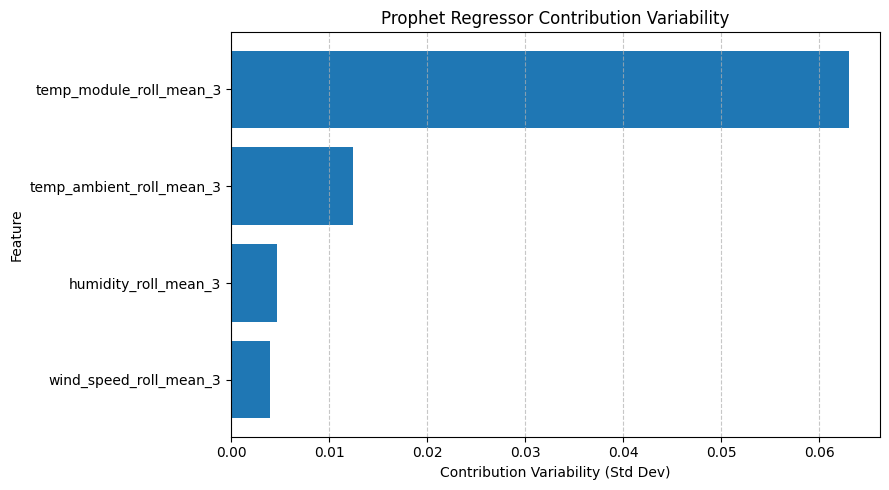

In [157]:
# Build and train the model with a custom daily seasonality
model_prophet = Prophet(
    growth='linear',
    daily_seasonality=False,
    weekly_seasonality=False,
    yearly_seasonality=False,
    changepoint_prior_scale=0.05,
)
model_prophet.add_seasonality(name='daily_solar', period=1, fourier_order=12)

for regressor in prophet_regressors:
    model_prophet.add_regressor(regressor)

print("Training Prophet...")
model_prophet.fit(prophet_train)

# Predict and evaluate on the test set
test_forecast = model_prophet.predict(prophet_test[['ds', 'floor'] + prophet_regressors])
test_preds = np.clip(test_forecast['yhat'].values, 0, None)

test_r2 = r2_score(prophet_test['y'], test_preds)
test_mae = mean_absolute_error(prophet_test['y'], test_preds)
test_rmse = np.sqrt(mean_squared_error(prophet_test['y'], test_preds))

print("\n--- Prophet test results ---")
print(f"Test R2   : {test_r2:.4f}")
print(f"Test MAE  : {test_mae:.4f}")
print(f"Test RMSE : {test_rmse:.4f}")

# Add Prophet's results to the shared model comparison table
prophet_metrics = {
    'Model': 'Prophet',
    'Val R2': np.nan,
    'Test R2': test_r2,
    'Test MAE': test_mae,
    'Test RMSE': test_rmse,
}
if 'benchmark_df' not in globals():
    benchmark_df = pd.DataFrame(columns=['Model', 'Val R2', 'Test R2', 'Test MAE', 'Test RMSE'])
benchmark_df = pd.concat([benchmark_df, pd.DataFrame([prophet_metrics])], ignore_index=True)
print("Prophet added to benchmark_df.")

# Component contribution variability — how much each regressor's
# contribution fluctuates in the forecast (not a formal importance score)
component_impacts = []
for regressor in prophet_regressors:
    if regressor in test_forecast.columns:
        impact = test_forecast[regressor].std()
        component_impacts.append({'Feature': regressor, 'Contribution_Variability': impact})

df_component_variability = pd.DataFrame(component_impacts).sort_values(
    by='Contribution_Variability', ascending=False
)

plt.figure(figsize=(9, 5))
plt.barh(
    df_component_variability['Feature'][::-1],
    df_component_variability['Contribution_Variability'][::-1],
    color='#1f77b4',
)
plt.xlabel('Contribution Variability (Std Dev)')
plt.ylabel('Feature')
plt.title('Prophet Regressor Contribution Variability')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [177]:
display(prophet_train.head())
prophet_train.value_counts().sum()
prophet_train.to_csv('prophet_train.csv', index=False)


,ds,y,temp_module_roll_mean_3,temp_ambient_roll_mean_3,wind_speed_roll_mean_3,humidity_roll_mean_3,floor
0,2020-05-15,0.0,23.591935,25.791132,3.01,69.91,0
1,2020-05-15,0.0,24.326362,26.397948,3.01,69.91,0
2,2020-05-15,0.0,25.060789,27.004764,3.01,69.91,0
3,2020-05-15,0.0,25.060789,27.004764,3.01,69.91,0
4,2020-05-15,0.0,25.060789,27.004764,3.01,69.91,0


In [178]:
import json
import joblib
import pandas as pd
from prophet.serialize import model_to_json

# 1. حفظ نموذج Prophet المدوَّر بالكامل (Full Prophet Model)
with open('prophet_model.json', 'w') as f:
  f.write(model_to_json(model_prophet))

# 2. حفظ جدول التنبؤات الكامل على مجموعة الاختبار (Test Forecast)
test_forecast.to_csv('prophet_test_forecast.csv', index=False)

# 3. حفظ بيانات التدريب والاختبار النهائية المقسمة
prophet_train.to_csv('prophet_train_data.csv', index=False)
prophet_test.to_csv('prophet_test_data.csv', index=False)

# 4. حفظ مقاييس الأداء وأهمية الفيتشرز (Metrics & Component Impact)
benchmark_df.to_csv('prophet_metrics.csv', index=False)
df_component_variability.to_csv('prophet_feature_importance.csv', index=False)

In [170]:
df_egypt_annual=pd.read_csv('/content/phase1_cluster0_candidates.csv')
df_egypt_annual.head()


,latitude,longitude,ALLSKY_SFC_SW_DWN_ANN,RH2M_ANN,T2M_ANN,WS2M_ANN
0,22.0,25.0,6.7795,24.30,22.93,2.85
1,22.0,25.5,6.7795,25.83,22.10,2.82
2,22.0,26.0,6.7493,26.28,22.31,2.73
3,22.0,26.5,6.7493,26.28,22.31,2.73
4,22.0,27.0,6.6991,26.41,22.65,2.89


In [171]:
df_egypt_annual.value_counts().sum()

np.int64(172)

In [172]:
# من بيانات الهند: احسب متوسط الفرق بين حرارة اللوح وحرارة الهواء
avg_module_ambient_offset = (df_feat_clean['temp_module'] - df_feat_clean['temp_ambient']).mean()
print(avg_module_ambient_offset)  # مثلاً هيطلع رقم زي 3-5 درجات تقريبًا

5.1577881916955075


/tmp/ipykernel_4919/3726567053.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hours = pd.date_range(reference_date, periods=24, freq='H')


Site: (22, 25)
Average Performance Ratio (24h): 0.4100
Predicted Power (kW): 66910.05


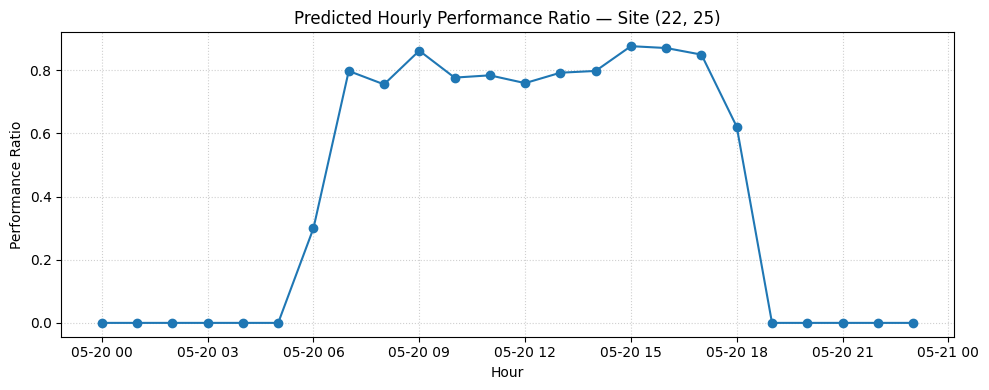

In [175]:
def predict_performance_ratio_egypt(lat_input, lon_input, reference_date='2020-05-20'):
    # 1. Look up the annual average weather for the selected coordinates
    site_row = df_egypt_annual[
        (df_egypt_annual['latitude'] == lat_input) &
        (df_egypt_annual['longitude'] == lon_input)
    ]
    if site_row.empty:
        raise ValueError(f"No data found for coordinates ({lat_input}, {lon_input})")
    site_row = site_row.iloc[0]

    ambient_approx = site_row['T2M_ANN']
    module_approx = ambient_approx + avg_module_ambient_offset
    humidity_approx = site_row['RH2M_ANN']
    wind_approx = site_row['WS2M_ANN']

    # 2. Build 24 hourly timestamps for one representative day
    #    (kept close to the original training period to avoid extrapolation)
    hours = pd.date_range(reference_date, periods=24, freq='H')

    future = pd.DataFrame({
        'ds': hours,
        'temp_module_roll_mean_3': module_approx,
        'temp_ambient_roll_mean_3': ambient_approx,
        'wind_speed_roll_mean_3': wind_approx,
        'humidity_roll_mean_3': humidity_approx,
        'floor': 0,
    })

    # 3. Predict all 24 hours and clip negative values to zero
    forecast = model_prophet.predict(future[['ds', 'floor'] + prophet_regressors])
    hourly_preds = np.clip(forecast['yhat'].values, 0, None)

    # 4. Average across the day as the representative performance ratio
    avg_ratio = hourly_preds.mean()

    return avg_ratio, hourly_preds, hours
Area_Egypt = 1600 * 600      # = 960,000 متر مربع
Efficiency_Egypt = 0.17      # = 17%

# Example usage
lat_input, lon_input = 22, 25
avg_ratio, hourly_preds, hours = predict_performance_ratio_egypt(lat_input, lon_input)

predicted_power_egypt = avg_ratio * Area_Egypt * Efficiency_Egypt

print(f"Site: ({lat_input}, {lon_input})")
print(f"Average Performance Ratio (24h): {avg_ratio:.4f}")
print(f"Predicted Power (kW): {predicted_power_egypt:.2f}")
daylight_pr = hourly_pr[hourly_pr > 0].mean()
print(f"Average Daytime Performance Ratio: {daylight_pr:.4f}")
# Optional: visualize the predicted daily curve
plt.figure(figsize=(10, 4))
plt.plot(hours, hourly_preds, marker='o', color='#1f77b4')
plt.title(f'Predicted Hourly Performance Ratio — Site ({lat_input}, {lon_input})')
plt.xlabel('Hour')
plt.ylabel('Performance Ratio')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()